<h1><center>Laboratorio 4: EDA en Pandas 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Ignacio Diaz  
- Nombre de alumno 2: Benjamin Fuentes

### **Link de repositorio de GitHub:** `https://github.com/BenjaminFuentesR/MDS7202`


## Reglas:

- **Grupos de 2 personas**
- Asistencia **obligatoria** a instrucciones del lab (viernes 16.15). Luego, pueden quedarse trabajando en las salas o irse.
- **No se revisarán entregas de personas ausentes**. 
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias. 
- Pueden usar cualquer matrial del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Aplicar los paradigmas y buenas prácticas de programación vistas hasta este momento.
- Utilizar las funciones de la librería `pandas` para realizar análisis exploratorio de datos
- Aplicar principios de visualización de datos vistos en clases para mostrar patrones en los datos


El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas de `pandas`.

## Descripción del laboratorio.

### Importamos librerias utiles 😸

In [11]:
# Libreria Core del lab.

# Libreria para plotear
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import Markdown, display
from scipy import stats

# Segmentación de Clientes en Tienda de Retail 🛍️

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

## 1.1 Cargar dataset [0.5 puntos]

Mr. Lepin Mora quien es el gerente de una cotizada tienda de retail en Europa, les solicita si pueden analizar los datos de algunas de sus tiendas.

Para esto, el área de ventas les entrega el 2 archivos: `online_retail_II.pickle` y `online_retail_I.pickle`.
- Cargue ambas fuentes y asegúrese que las columnas son del tipo correcto como en el ejemplo de df_retail_1 visualizando los datos para determinar el tipo. Para fechas, puede usar `'datetime64[ns]'`
- Combine los dataframes en uno solo. ¿Qué función debe utilizar en este caso?
- Señale las columnas que componen el dataset combinado, el tipo de variable presente en cada columna y comente que representa cada una de estas.

**Respuesta:**

Se utilizó pd.merge para combinar los dataframes ya que comparten la columna Invoice pero con información distinta.

las columnas son:
- Invoice (category): Número de factura
- StockCode (category): Código del producto
- Description (str): Descripción del producto
- Quantity (int64): Cantidad vendida
- Price (float64): Precio unitario
- Customer ID (category): Identificador del cliente
- Country (object): País del cliente
- InvoiceDate (datetime64): Fecha de la compra

In [12]:
df_retail_1 = pd.read_pickle("online_retail_I.pickle")
df_retail_1 = df_retail_1.astype(
    {
        "Invoice": "category",
        "StockCode": "category",
        "Description": str,
        "Customer ID": "category",
    }
)
df_retail_1.head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom


In [119]:
df_retail_2 = pd.read_pickle("online_retail_II.pickle")

# Resto de su código

df_retail_2 = df_retail_2.astype({"Invoice": "category"})
df_retail = pd.merge(df_retail_1, df_retail_2, on="Invoice")
df_retail.head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom,2009-12-01 07:45:00


## 1.2 Analisís Explotatorio de los Datos [0.5 puntos] 

En base a la primera visualización del dataset, *Don Mora* le solicita que realicen un análisis exploratorio de los datos, para esto les deberán realizar un análisis univariado y multivariado. De la revisión, ustedes deben explicar potenciales anomalías visualizadas y señalar si existe la necesidad de realizar una limpieza de datos.

Explique a que nos referimos con análisis univariable, multivariable y de datos faltantes. ¿Qué beneficios nos otorga estudiar estos datos?. Sea conciso con su respuesta y no escriba mas de 5 líneas para su respuesta.

**Respuesta a la Pregunta:**

> Respuesta Aquí 

El análisis univariable estudia cada variable por separado para entender su distribución, valores extremos y anomalias. El multivariable analiza relaciones entre variables, como correlaciones. El análisis de datos faltantes permite identificar qué columnas tienen nulos y en qué proporción. Estudiar estos datos nos permite detectar errores antes de modelar y tomar mejores decisiones en la posterior limpieza de datos.

### 1.2.1 Análisis Univariado [1.5 Puntos]

A continuación, se le presentan dos funciones para analizar los datos que componen un dataframe. La primera de estas es la función ``profile_serie()`` la cual recibe una serie y le entrega un análisis detallado de los datos que conforman dicha serie. 

Ejecute la funcion ``profile_serie()`` sobre cada serie para realizar un análisis univariado de estas. A continuación, comente acerca de el comportamiento de cada variable según las estadísticas descriptivas y los gráficos generados.

In [14]:
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype, is_timedelta64_dtype


def profile_serie(serie_in, n_samples=1000, random_state=42):
    serie = serie_in.copy()

    profile = pd.Series(dtype="object")
    profile["Type"] = serie.dtype
    profile = pd.concat([profile, serie.describe()])

    # profile = pd.Series([])

    if is_numeric_dtype(serie):
        profile["Negative"] = (serie < 0).sum()
        profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Zeros"] = (serie == 0).sum()
        profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Kurt"] = serie.kurt()
        profile["Skew"] = serie.skew()

    profile[" "] = " "  # espacio

    profile["Missing cells"] = serie.isnull().sum()
    profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
    profile["Duplicate rows"] = serie.duplicated(False).sum()
    profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
    profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

    # profile = pd.concat([profile, description])

    profile = profile.rename(
        index={
            "count": "Number of observations",
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "max": "Max",
            "unique": "Unique",
            "top": "Top",
            "freq": "Freq",
        }
    )
    no_outliers_fig = None

    if is_numeric_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name} - With Outliers")

        no_outliers = sampled_serie.loc[(np.abs(stats.zscore(sampled_serie)) < 3)]
        # zscore = https://es.wikipedia.org/wiki/Unidad_tipificada

        no_outliers_fig = px.histogram(no_outliers, marginal="box", title=f"{serie.name} - Without Outliers")

    elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")

    else:
        count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
        fig = px.bar(
            x=count[serie.name].astype(str),
            y=count["Count"],
            title=f"100 Most common categories of {serie.name}",
        )
    display(Markdown(f"## {serie.name} Profile"))
    display(profile)
    fig.show()

    if no_outliers_fig:
        no_outliers_fig.show()

    # return fig, profile

In [15]:
profile_serie(df_retail["Price"])

## Price Profile

Type                            float64
Number of observations         525461.0
Mean                           4.688834
Std                          146.126914
Min                           -53594.36
25%                                1.25
50%                                 2.1
75%                                4.21
Max                            25111.09
Negative                              3
Negative (%)                      0.0 %
Zeros                              3687
Zeros (%)                         0.7 %
Kurt                       64868.344873
Skew                        -140.768446
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   524485
Duplicate rows (%)              99.81 %
Total size in memory      4203820 bytes
dtype: object

Price es float64 sin valores nulos. El precio promedio es 4.69 con la mayoría de productos bajo 2.10. Hay 3 valores negativos (mínimo -53.594) y 3.687 ceros, ambos imposibles para un precio real, deben eliminarse en la limpieza. Los gráficos confirman una distribución muy sesgada con outliers extremos.

In [16]:
profile_serie(df_retail["Quantity"])

## Quantity Profile

Type                              int64
Number of observations         525461.0
Mean                          10.337667
Std                           107.42411
Min                             -9600.0
25%                                 1.0
50%                                 3.0
75%                                10.0
Max                             19152.0
Negative                          12326
Negative (%)                     2.35 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                        6277.666908
Skew                          36.044617
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525122
Duplicate rows (%)              99.94 %
Total size in memory      4203820 bytes
dtype: object

Quantity es int64 sin valores nulos. La cantidad promedio es 10 unidades con el 50% bajo 3. Hay 12.326 valores negativos (2.35%, mínimo -9600), imposibles para ventas reales. El máximo de 19.152 confirma la existentcia de outliers extremos. Sin outliers la distribución se concentra entre 0 y 20.

In [17]:
profile_serie(df_retail["InvoiceDate"])

## InvoiceDate Profile

Type                                     datetime64[ns]
Number of observations                           525461
Mean                      2010-06-28 11:37:36.619958528
Min                                 2009-12-01 07:45:00
25%                                 2010-03-21 12:20:00
50%                                 2010-07-06 09:51:00
75%                                 2010-10-15 12:45:00
Max                                 2010-12-09 20:01:00
                                                       
Missing cells                                         0
Missing cells (%)                                 0.0 %
Duplicate rows                                   520408
Duplicate rows (%)                              99.04 %
Total size in memory                      4203820 bytes
dtype: object

InvoiceDate es datetime64 sin valores nulos. Los datos cubren desde diciembre 2009 hasta diciembre 2010. El histograma muestra distribución uniforme durante el año con un peak en noviembre-diciembre 2010, explicable por el aumento de ventas en época navideña. No se detectam anomalias.

In [18]:
profile_serie(df_retail["Customer ID"])

## Customer ID Profile

Type                           category
Number of observations         417534.0
Unique                           4383.0
Top                             14911.0
Freq                             5710.0
                                       
Missing cells                    107927
Missing cells (%)               20.54 %
Duplicate rows                   525327
Duplicate rows (%)              99.97 %
Total size in memory      1086118 bytes
dtype: object

Customer ID es category con 4.383 clientes únicos. Tiene 107.927 valores nulos (20.54%), posiblemente compras sin cuenta registrada. El cliente más frecuente es el 14911 con 5.710 transacciones. El gráfico muestra distribución muy desigual donde pocos clientes concentran la mayoría de compras, y una gran cantidad de clientes concentran un numero menor y casi uniforme de compras.

In [19]:
profile_serie(df_retail["Country"])

## Country Profile

Type                              object
Number of observations            525461
Unique                                40
Top                       United Kingdom
Freq                              485852
                                        
Missing cells                          0
Missing cells (%)                  0.0 %
Duplicate rows                    525461
Duplicate rows (%)               100.0 %
Total size in memory       4203820 bytes
dtype: object

Country es object sin valores nulos, con 40 países únicos. United Kingdom domina con 485.852 transacciones (92% del dataset), lo esperado para una tienda europea. Se observa una categoría "Unspecified" que no es necesario eliminar.

In [20]:
profile_serie(df_retail["Description"])

## Description Profile

Type                                                     str
Number of observations                                522533
Unique                                                  4681
Top                       WHITE HANGING HEART T-LIGHT HOLDER
Freq                                                    3549
                                                            
Missing cells                                           2928
Missing cells (%)                                     0.56 %
Duplicate rows                                        525198
Duplicate rows (%)                                   99.95 %
Total size in memory                           4203820 bytes
dtype: object

Description es str con 4.681 productos únicos y 2.928 valores nulos (0.56%). El producto más frecuente es "WHITE HANGING HEART T-LIGHT HOLDER" con 3.549 apariciones. Se observa la entrada "Manual" que parece un error de registro y no un producto real, debería considerarse en la limpieza de datos.

In [21]:
profile_serie(df_retail["Invoice"])

## Invoice Profile

Type                           category
Number of observations           525461
Unique                            28816
Top                              537434
Freq                                675
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   517456
Duplicate rows (%)              98.48 %
Total size in memory      2338390 bytes
dtype: object

Invoice es de tipo category con 28.816 facturas únicas y sin valores nulos. La factura más frecuente es la 537434 con 675 productos, lo que indica que una misma factura puede contener múltiples productos. Finalomente no se encuentran anomalías destacables.

In [14]:
profile_serie(df_retail["StockCode"])

## StockCode Profile

Type                           category
Number of observations           525461
Unique                             4632
Top                              85123A
Freq                               3516
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525026
Duplicate rows (%)              99.92 %
Total size in memory      1220246 bytes
dtype: object

StockCode es category con 4.632 códigos únicos y sin valores nulos. El producto más frecuente es el 85123A con 3.516 apariciones. Se observa la categoría "M" y "m", que está asociado al producto con descripción igual a "Manual", por lo que se decide no eliminarlo. Pocos productos concentran la mayor cantidad de transacciones.

### 1.2.2 Análisis Multivariado y Datos Faltantes [1 ptos]

En segundo lugar encontrará la función ``profile_df()`` que recibe un dataframe como entrada y realiza un análisis bivariado de todas las variables numéricas que conforman el dataframe, un analisis de la correlación de Pearson entre las variables numericas del dataframe y la matriz de datos faltantes.

Utilice esta función en el dataframe. Comente sobre los patrones que observa. Luego responda:
- Existen correlaciones relevantes observadas?
- Qué aspectos revelan estos gráficos acerca de la limpieza de los datos?

RESPUESTA: 

El análisis bivariado muestra que Quantity vs Price presenta valores extremos negativos en ambos ejes, confirmando los outliers detectados en el análisis univariado. No se observa correlación clara entre las variables. En la matriz de correlación, Quantity, Price e InvoiceDate no muestran correlación entre sí, lo que indica que el precio y la cantidad vendida son independientes.

La matriz de datos faltantes confirma que Customer ID es la columna con más valores nulos, seguida por Description con algunos nulos dispersos. El resto de columnas están completas. No existen correlaciones relevantes entre las variables numéricas. Los gráficos confirman la necesidad de limpiar valores negativos en Price y Quantity, y tratar los nulos de Customer ID y Description.

In [55]:
def profile_df(dataframe_in):
    df = dataframe_in.copy()

    list_type = []
    for col in list(df.columns):
        if is_numeric_dtype(df[col]) or is_datetime64_any_dtype(df[col]) or is_timedelta64_dtype(df[col]):
            list_type.append(col)

    display(Markdown("## Bivariant Analysis:"))
    for i in range(len(list_type)):
        for j in range(i + 1, len(list_type)):
            plt.scatter(df[list_type[i]], df[list_type[j]])
            plt.xlabel(list_type[i])
            plt.ylabel(list_type[j])
            plt.title(f"{list_type[i]} v/s {list_type[j]}")
            plt.show()

    display(Markdown("## Correlation:"))
    fig_corr = px.imshow(df[list_type].corr())
    fig_corr.show()

    display(Markdown("## Missing Matrix:"))
    fig, ax = plt.subplots(figsize=[15, 10])
    msno.matrix(df, ax=ax, sparkline=False)

## Bivariant Analysis:

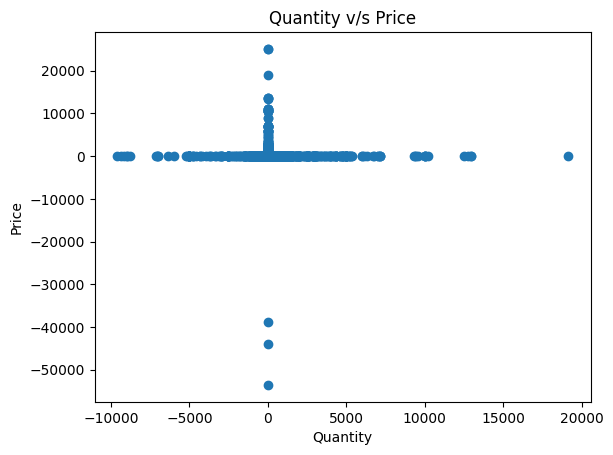

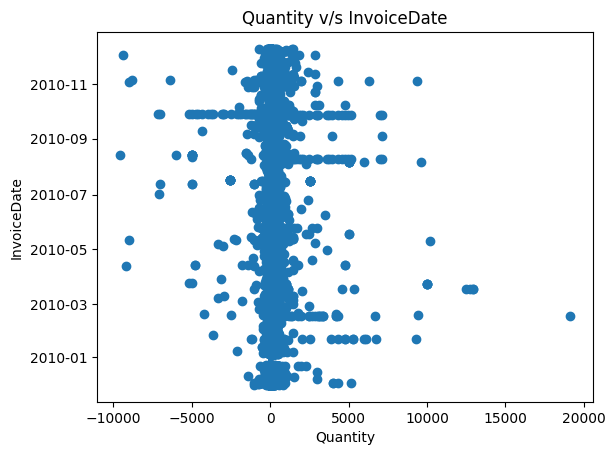

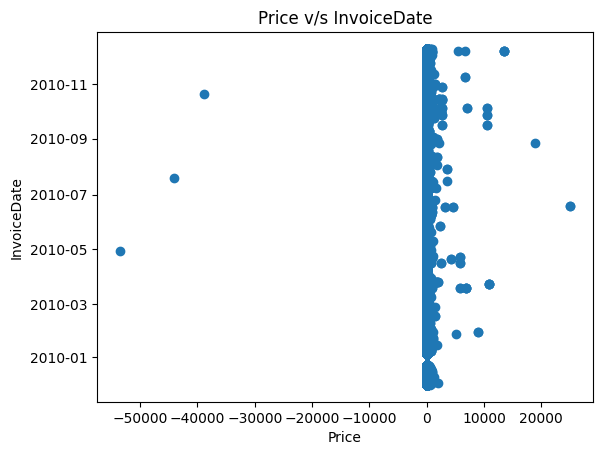

## Correlation:

## Missing Matrix:

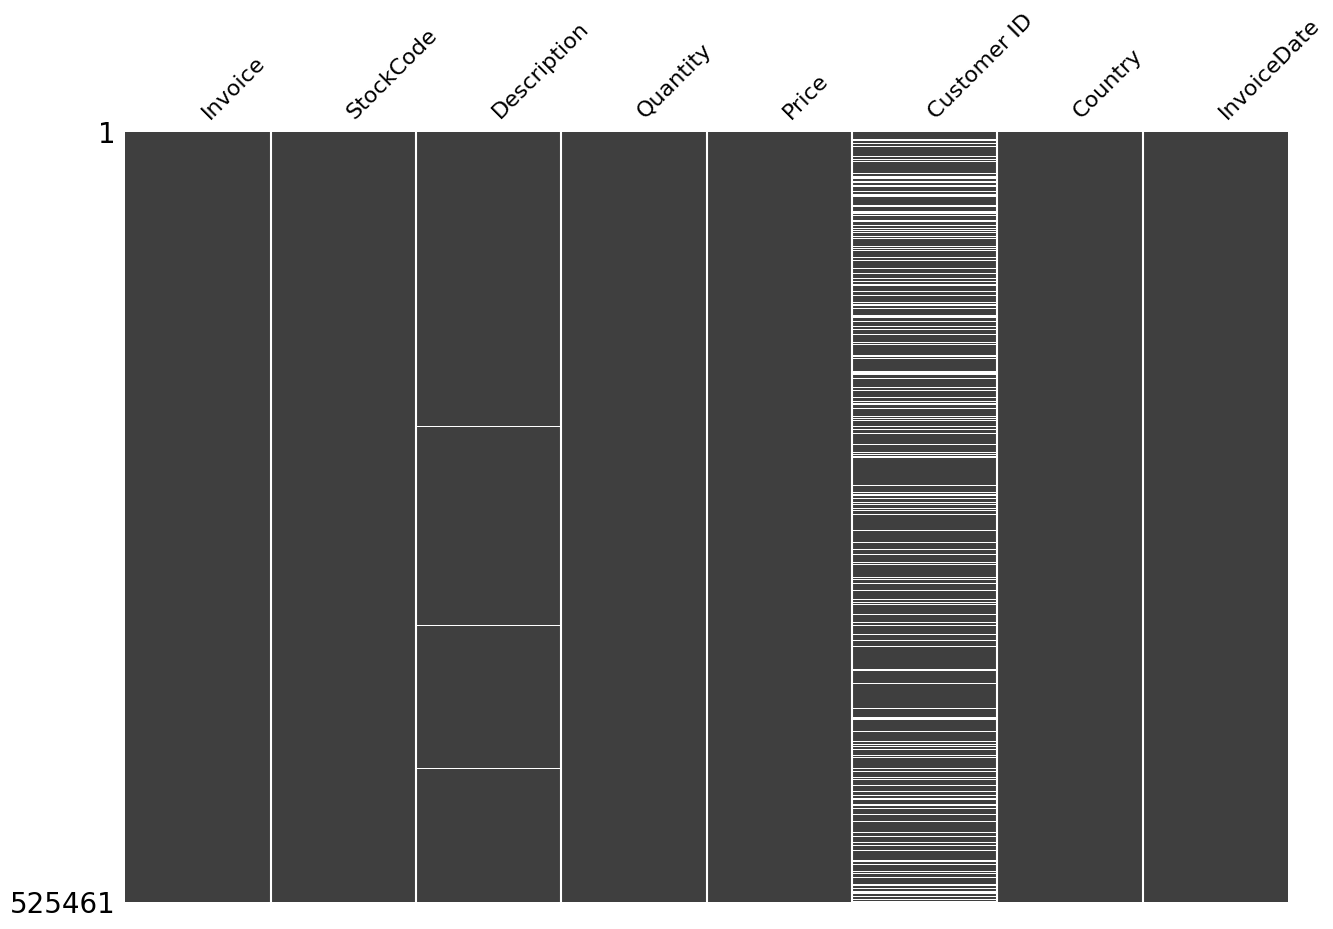

In [56]:
profile_df(df_retail)

### 1.2.3 Limpieza de Datos [1 pto]

Como pudo ver en las secciones anteriores, los datos presentan valores erroneos, es por esto que se le solicita que realice una función que permita limpiar el dataset. Realice esta función en base observaciones propias y considere como **imposible tener cantidades negativas** en las ventas. Investigue sobre métodos para eliminar outliers usando pandas

Una vez realizada la función, realice nuevamente el análisis exploratorio y comente las principales diferencias.

**Respuesta:**

In [ ]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Función que permite limpiar un dataset"""

    df_resultado = df.copy()

    # Se encontró que se pueden eliminar outliers usando el rango intercuartílico, en este caso, para Quantity para el límite superior.
    Q1 = df["Quantity"].quantile(0.25)
    Q3 = df["Quantity"].quantile(0.75)

    lim = Q3 + 1.5 * (Q3 - Q1)

    # Se eliminan registros anómalos de cantidad de ventas y precios.
    df_resultado = df_resultado.query(f"(0 < Quantity < {lim}) and (0 < Price)")

    # Se agrega nueva categoría a columna Customer ID.
    df_resultado["Customer ID"] = df_resultado["Customer ID"].cat.add_categories("No registrado")

    # Custormer ID nulos se nombran como: No registrado.
    df_resultado["Customer ID"] = df_resultado["Customer ID"].fillna("No registrado")

    # Description nulos se nombran como: Sin descripción.
    df_resultado["Description"] = df_resultado["Description"].fillna("Sin descripción")

    return df_resultado.copy()

In [60]:
# Se limpia el dataset.
df_retail_clean = clean_data(df_retail)

In [61]:
# Análisis exploratorio univariable

# Columnas del dataframe.
cols = df_retail_clean.columns

for col in cols:
    profile_serie(df_retail_clean[col])

## Invoice Profile

Type                           category
Number of observations           456588
Unique                            19216
Top                              537434
Freq                                672
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   454702
Duplicate rows (%)              99.59 %
Total size in memory      5853216 bytes
dtype: object

## StockCode Profile

Type                           category
Number of observations           456588
Unique                             4189
Top                              85123A
Freq                               2717
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   456404
Duplicate rows (%)              99.96 %
Total size in memory      4735072 bytes
dtype: object

## Description Profile

...

Type                           category
Number of observations           456588
Unique                             4172
Top                       No registrado
Freq                             102610
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   456498
Duplicate rows (%)              99.98 %
Total size in memory      4733088 bytes
dtype: object

## Country Profile

Type                              object
Number of observations            456588
Unique                                40
Top                       United Kingdom
Freq                              427271
                                        
Missing cells                          0
Missing cells (%)                  0.0 %
Duplicate rows                    456588
Duplicate rows (%)               100.0 %
Total size in memory       7305408 bytes
dtype: object

## InvoiceDate Profile

Type                                     datetime64[ns]
Number of observations                           456588
Mean                      2010-06-28 19:18:18.692606464
Min                                 2009-12-01 07:45:00
25%                                 2010-03-21 10:49:00
50%                                 2010-07-06 09:52:00
75%                                 2010-10-17 14:54:00
Max                                 2010-12-09 20:01:00
                                                       
Missing cells                                         0
Missing cells (%)                                 0.0 %
Duplicate rows                                   454984
Duplicate rows (%)                              99.65 %
Total size in memory                      7305408 bytes
dtype: object

Se puede observar que tanto Price como Quantity ya no tienen valores menores o iguales a 0, sin embargo, solo se eliminaron aquellas muestras con valores demasiados altos (outliers) para Quantity, porque para price no se sabe con seguridad si realmente corresponde a un outlier o no. Por esa razón, la media de la cantidad bajó considerablemente y la mediana del precio también.

Por otro lado, tanto para Customer ID como para Description se reemplazaron los nulos por un un string o categoría indicando que es desconocido.

Para Customer ID, Invoice y Stockcode se notó que bajó el número de valores únicos. El más común para Customer ID ahora son aquellos que no tienen registrado un ID. El más común para Invoice y para Stockcode no cambia.

Respecto a InvoceDatey Country, no hubieron cambios destacables.

## Bivariant Analysis:

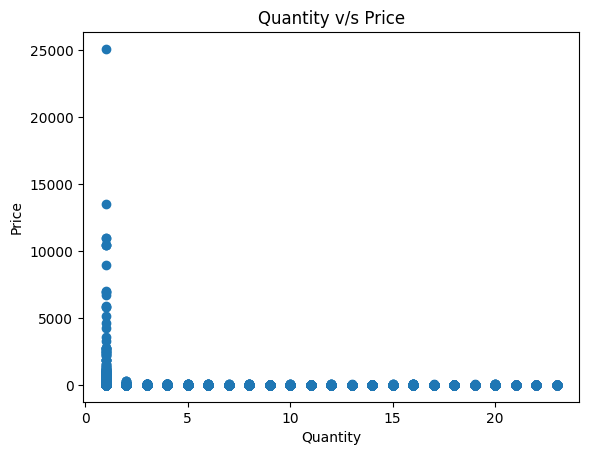

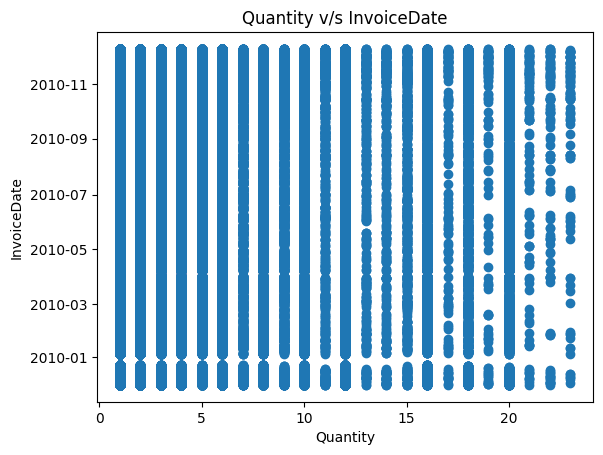

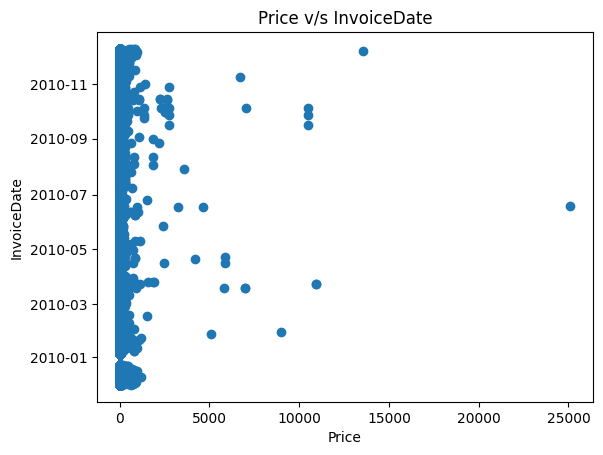

## Correlation:

## Missing Matrix:

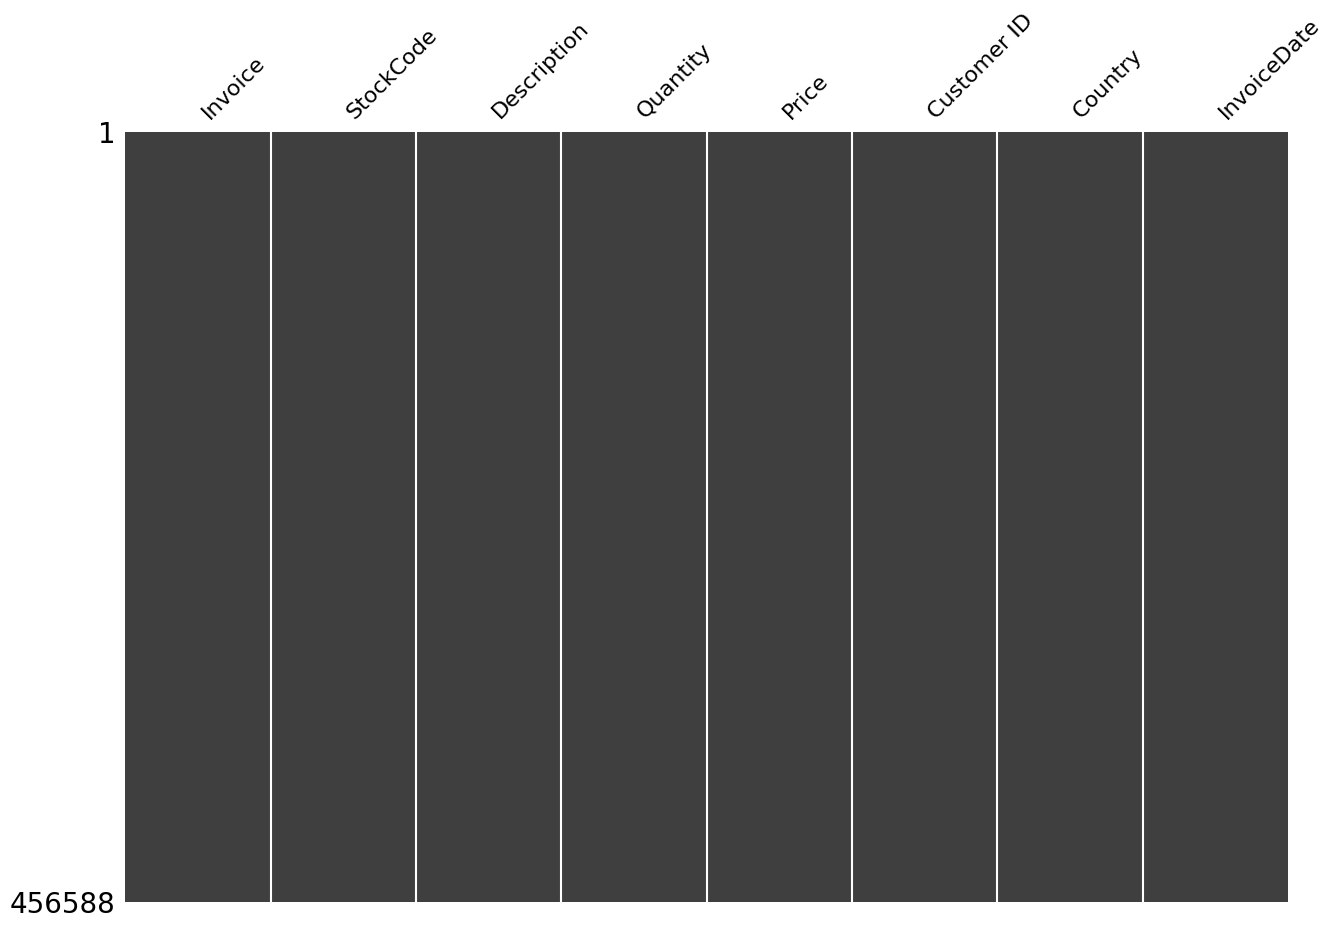

In [62]:
# Análisis exploratorio multivariable

profile_df(df_retail_clean)

Ahora, con el dataset limpiado, Quantity vs Price ya no muestra valores negativos pero si algunos extremos positivos para el precio pero ya no para la cantidad. Se sigue sin observar alguna correlación, y las cantidades a lo largo del año se igualaron relativamente.

Respecto a la matriz de datos, faltantes, ya no se observan aquellos nulos captados antes, al ser reemplazados por un string o catergoría que los identificase.

### 1.2.4 Obtención de TOPs [0.75 ptos]

Sin considerar los comentarios realizados en la sección 1.2 , *Don Mora* les pide obtener el **Top de 30 productos que generan más ganancias** para la tienda de retail. Deben considerar todo el registro temporal presente en el dataset y entregar la información en un gráfico de barras de los ingresos/cantidades v/s el nombre de los productos (Utilice `plotly`). ¿Los artículos más vendidos son los mismos que generan más ganancias?, Comente los resultados obtenidos.

**Resultados:**

In [102]:
# Se crea una copia para modificar.
df_retail_mod = df_retail.copy()

# Se cambia el tipo para graficar.
df_retail_mod["StockCode"] = df_retail_mod["StockCode"].astype(str)

# Se agrega la columna de ganancia por compra.
df_retail_mod["Profit"] = df_retail["Quantity"] * df_retail["Price"]

# Se agrupa por el código del producto y se suman las ganancias.
topProductos = df_retail_mod.groupby("StockCode")["Profit"].sum().sort_values(ascending=False).reset_index()

# Se grafica productos con más ganancias.
fig = px.bar(topProductos.iloc[:30, :], x="StockCode", y="Profit", title="Top 30 Productos con más Ganancias")
fig.show()


# Se agrupa por código del producto y se suman cantidades.
productosMasVendidos = df_retail_mod.groupby("StockCode")["Quantity"].sum().sort_values(ascending=False).reset_index()

# Se grafica productos más vendidos.
fig = px.bar(productosMasVendidos.iloc[:30, :], x="StockCode", y="Quantity", title="Top 30 Productos más vendidos")
fig.show()

Se puede observar que los productos con más ganancias no son los mismos que los más vendidos. Probablemente sea por los outliers que posee la variable cantidad que infla algunos productos. Además, existen varios productos con cantidades y precios negativos que restan valor y cantidad final. Además si ambos son negativos, entonces entregará un valor positivo, generando aun más errores en el resultado.

### 1.2.5 Visualización del registro temporal [0,75 ptos]

El dueño del retail en su afán por saber más sobre los datos de su firma les solicita que grafiquen las ventas respecto al tiempo. Con esto les aclara que durante el día tienen muchas variaciones en sus ventas, por lo que les recomienda que consideren el registro temporal como `año-mes-día`. ¿Es posible observar datos extraños?, Comente lo que observa del gráfico.

In [124]:
# Se considera una venta como ganancia.


def plot_ventas(dataframe):
    # Se hace una copia del dataframe.
    df_mod = dataframe.copy()

    df_mod["Profit"] = df_mod["Quantity"] * df_mod["Price"]

    # Se agrega columna con solo fecha.
    df_mod["date"] = df_mod["InvoiceDate"].dt.date

    # Se agrupa por fecha y se suman las ganancias.
    cantidadFecha = df_mod.groupby("date")["Profit"].sum().reset_index()

    # Se grafica productos con más ganancias.
    fig = px.line(cantidadFecha, x="date", y="Profit", title="Ganancias en cada fecha")
    fig.show()

In [125]:
# Se grafica.
plot_ventas(df_retail)

Se puede observar que existen varios valores extraños al ser menores a 0, lo que no tiene sentido si son ganancias. Esto nuevamente ocurre porque los datos utilizados poseen valores erróneos en las cantidades y precios.

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>